# Citation Cheat Codes: Do Certain Institutions or Topics Influence Citation Counts for Academic Research?
Denise Godinez 

## Research Question
**Given** the OpenAlex tables “Works,” “Works Authorships,” and "Works Topics" provide information about citation counts, authors, the institution that published these works, and the topics of these works between 2019 and 2024.

**Then** we aim to identify which institutions and combinations of institutions, and which topics and combination of topics are most frequently associated with highly cited research during this period.

**How** we will approach this is by each highly cited paper we will look at its authoring institutions and its topics to analyze which institutions frequently appear together in impactful research. Using frequent pattern mining we will identify recurring patterns and determine which combinations are most associated with highly cited works.

## Research Subfields in Highly Cited Papers

---
## Step 1: Imports & Configuration

In [46]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)

# Path to the OpenAlex parquet 
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"

# minimum citations for a paper to be considered "highly cited" 
CITATION_THRESHOLD = 50  
MIN_YEAR = 2019           
MAX_YEAR = 2024  
# minimum amount of papers a subfield/pair must appear in
MIN_SUPPORT = 0.0025 

---
## Step 2: Load Highly-Cited Works
Use push-down predicates to read only the rows we need from the large works parquet table. We are looking for papers published between 2019–2024 with at least 50 citations.

In [47]:
print("Loading works...")

works_df = pd.read_parquet(
    PARQUET_PATH / 'works',
    # Only load the columns we actually need
    columns=['work_id', 'title', 'publication_year', 'cited_by_count'],
    filters=[
        [
            ('publication_year', '>=', MIN_YEAR),
            ('publication_year', '<=', MAX_YEAR),
            # highly cited papers only
            ('cited_by_count', '>=', CITATION_THRESHOLD),
            # complete metadata required
            ('has_complete_institution_info', '==', True),
            # must have keyword tags
            ('has_keywords', '==', True),                      
        ]
    ],
)

print(f"Loaded {len(works_df):,} highly-cited works")
works_df.head()

Loading works...
Loaded 674,014 highly-cited works


,work_id,title,publication_year,cited_by_count
0,4223541591,A comprehensive review on the adsorption of heavy metals by zeolite imidazol...,2022,184
1,3025854696,Self-harm with suicidal and non-suicidal intent in young people in sub-Sahar...,2020,67
2,2936380844,A First Implementation of Underwater Communications in Raw Water Using the 4...,2019,84
3,2047643587,Songs and Musicians in the Fifteenth Century,2024,86
4,2909533002,Similarity and Self-Esteem in Downward Comparison,2024,175


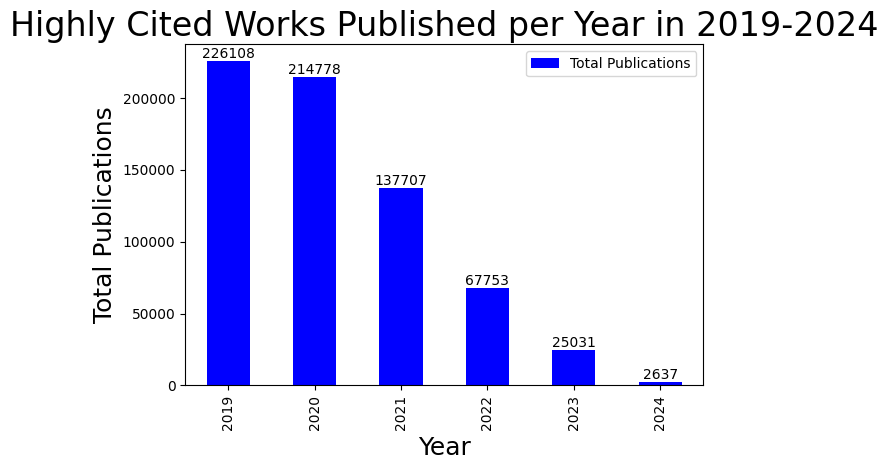

In [48]:
# Plot total highly cited works published per year
hc_works_per_year = works_df.groupby('publication_year')['work_id'].count()

hc_works_by_year = hc_works_per_year.plot.bar(color='blue')

hc_works_by_year.set_title('Highly Cited Works Published per Year in 2019-2024', fontsize=24, color='black')
hc_works_by_year.set_xlabel('Year', fontsize=18, color='black')
hc_works_by_year.set_ylabel('Total Publications', fontsize=18, color='black')
hc_works_by_year.legend(['Total Publications'])

hc_works_by_year.bar_label(hc_works_by_year.containers[0], fmt='%d', label_type='edge', color='black')

plt.tight_layout()
plt.show()

---
## Step 3: Load Topic Data for Those Works
Fetch rows from the works_topics table that correspond to the papers loaded above.

In [49]:
# Convert to list
work_ids = list(works_df.work_id)
print(f"Fetching topics for {len(work_ids):,} works...")

works_topics_df = pd.read_parquet(
    PARQUET_PATH / 'works_topics',
    # Only load rows matching the work_ids
    filters=[['work_id', 'in', work_ids]],
)

print(f"Loaded {len(works_topics_df):,} topic rows")
print(f"Columns: {list(works_topics_df.columns)}")
works_topics_df.head(10)

Fetching topics for 674,014 works...
Loaded 1,994,446 topic rows
Columns: ['work_id', 'publication_year', 'is_primary_topic', 'score', 'topic_id', 'topic_name', 'subfield_id', 'subfield_name', 'field_id', 'field_name', 'domain_id', 'domain_name']


,work_id,publication_year,is_primary_topic,score,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
0,4223541591,2022,True,0.9999,10096,Metal-Organic Frameworks: Synthesis and Applications,1604,Inorganic Chemistry,16,Chemistry,3,Physical Sciences
1,4223541591,2022,False,0.9896,10016,Adsorption and biosorption for pollutant removal,2312,Water Science and Technology,23,Environmental Science,3,Physical Sciences
2,4223541591,2022,False,0.9780,12038,Covalent Organic Framework Applications,2505,Materials Chemistry,25,Materials Science,3,Physical Sciences
3,3025854696,2020,True,0.9999,10376,Suicide and Self-Harm Studies,3203,Clinical Psychology,32,Psychology,2,Social Sciences
4,3025854696,2020,False,0.9861,10182,Child and Adolescent Psychosocial and Emotional Development,3203,Clinical Psychology,32,Psychology,2,Social Sciences
5,3025854696,2020,False,0.9546,10272,Mental Health Treatment and Access,3207,Social Psychology,32,Psychology,2,Social Sciences
6,2936380844,2019,True,0.9999,11192,Underwater Vehicles and Communication Systems,2212,Ocean Engineering,22,Engineering,3,Physical Sciences
7,2936380844,2019,False,0.9983,12697,Water Quality Monitoring Technologies,2312,Water Science and Technology,23,Environmental Science,3,Physical Sciences
8,2936380844,2019,False,0.9905,10080,Energy Efficient Wireless Sensor Networks,1705,Computer Networks and Communications,17,Computer Science,3,Physical Sciences
9,2047643587,2024,True,0.7900,12409,Reformation and Early Modern Christianity,1202,History,12,Arts and Humanities,2,Social Sciences


In [50]:
# Save merged data as parquet to quickly reload in event of a kernel crash
works_topics_df.to_parquet(path='/home/jupyter-dgodinez1@luc.edu/works_topics.parquet')

In [51]:
works_topics_df = pd.read_parquet('/home/jupyter-dgodinez1@luc.edu/works_topics.parquet')

In [52]:
# Sanity check
display(works_topics_df.head())

,work_id,publication_year,is_primary_topic,score,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
0,4223541591,2022,True,0.9999,10096,Metal-Organic Frameworks: Synthesis and Applications,1604,Inorganic Chemistry,16,Chemistry,3,Physical Sciences
1,4223541591,2022,False,0.9896,10016,Adsorption and biosorption for pollutant removal,2312,Water Science and Technology,23,Environmental Science,3,Physical Sciences
2,4223541591,2022,False,0.9780,12038,Covalent Organic Framework Applications,2505,Materials Chemistry,25,Materials Science,3,Physical Sciences
3,3025854696,2020,True,0.9999,10376,Suicide and Self-Harm Studies,3203,Clinical Psychology,32,Psychology,2,Social Sciences
4,3025854696,2020,False,0.9861,10182,Child and Adolescent Psychosocial and Emotional Development,3203,Clinical Psychology,32,Psychology,2,Social Sciences


---
## Step 4: Inspect the Topic Score Distribution
We do this to understand how strongly topics are associated with papers before deciding whether to apply a score threshold.

count    1.994446e+06
mean     9.906687e-01
std      2.945952e-02
min      1.070000e-02
25%      9.910000e-01
50%      9.976000e-01
75%      9.996000e-01
max      1.000000e+00
Name: score, dtype: float64


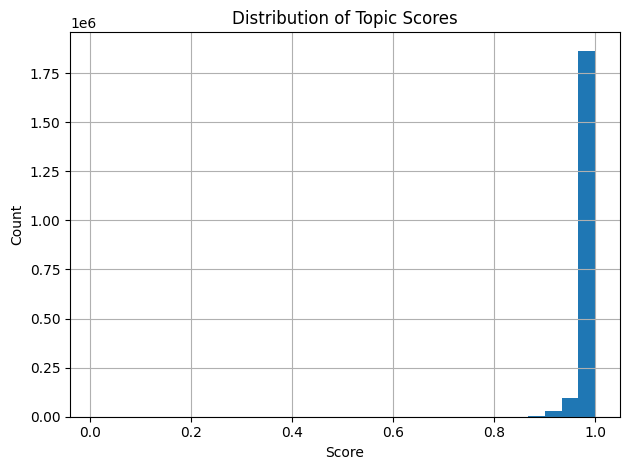

In [53]:
# Summary statistics
print(works_topics_df['score'].describe())

# Plot the distribution to visually check skew and decide on a score threshold
works_topics_df['score'].hist(bins=30)
plt.title("Distribution of Topic Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Most of the topic assignments have scores close to 1. This means that we are highly confident in the subfield assignments for these papers. We don't have to apply a score threshold to filter out papers who have weak subfields. 

---
## Step 5: Build Transactions
- Each paper is a transaction
- Each research subfield assigned to that paper is an item

We use subfield_name rather than topic_name because subfields appear frequently enough across papers to produce meaningful support values. Papers with fewer than 2 subfields are dropped since they cannot contribute to co-occurrence patterns.

In [54]:
# No score threshold applied
# so all assignments are included regardless of score
strong_topics_df = works_topics_df.copy()

# Group by paper 
# Each paper is assigned to its groups of subfields
work_topics = (
    strong_topics_df
    .groupby('work_id')['subfield_name']
    .apply(set)
)

# Drop papers with fewer than 2 subfields
work_topics = work_topics[work_topics.apply(len) >= 2]

print(f"Papers with >=2 subfields: {len(work_topics):,}")

# Convert to list-of-lists (mlxtend format)
transactions = [list(topics) for topics in work_topics]

print("\nSample transaction:")
print(transactions[0])

Papers with >=2 subfields: 615,539

Sample transaction:
['Economics and Econometrics', 'Gender Studies']


---
## Step 6: Sample for Memory Efficiency
With many transactions, building a full boolean matrix would make the kernel crash. A random sample of 50,000 papers is enough to return meaningful data. 

In [55]:
import random

# 50k papers is enough 
SAMPLE_SIZE = 50_000 

# Fix the seed so re-running this cell gives the same sample every time
random.seed(42)
if len(transactions) > SAMPLE_SIZE:
    transactions = random.sample(transactions, SAMPLE_SIZE)

print(f"Working with {len(transactions):,} transactions")
print(f"Sample transaction: {transactions[0]}")

Working with 50,000 transactions
Sample transaction: ['Economics and Econometrics', 'Statistics, Probability and Uncertainty', 'Cardiology and Cardiovascular Medicine']


---
## Step 7: Encode Transactions as a Boolean Matrix
TransactionEncoder converts the list-of-lists into a boolean DataFrame where:
- Rows = papers (transactions)
- Columns = unique subfields (items)
- Values = True if that subfield appears in that paper

In [56]:
# First learn all unique subfields, then one-hot encode each transaction
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

# Wrap in a DataFrame
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {te_df.shape}")
print(f"  {te_df.shape[0]:,} rows  (papers / transactions)")
print(f"  {te_df.shape[1]:,} cols  (unique subfields / items)")

sparsity = (~te_df).sum().sum() / te_df.size
print(f"\nSparsity: {sparsity:.3%} of values are False")
print(f"Column dtype (item keys): {te_df.columns.dtype}")

te_df.head(3)

Matrix shape: (50000, 239)
  50,000 rows  (papers / transactions)
  239 cols  (unique subfields / items)

Sparsity: 98.922% of values are False
Column dtype (item keys): str


,Accounting,Acoustics and Ultrasonics,Aerospace Engineering,Aging,Agronomy and Crop Science,Algebra and Number Theory,Analytical Chemistry,Anesthesiology and Pain Medicine,Animal Science and Zoology,Anthropology,...,Theoretical Computer Science,"Tourism, Leisure and Hospitality Management",Toxicology,Transplantation,Transportation,Urban Studies,Urology,Virology,Visual Arts and Performing Arts,Water Science and Technology
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


---
## Step 8: Running Apriori to Find Frequent Itemsets
Using Apriori finds all subfield combinations whose support meets our minimum threshold.

We use min_support = 0.0025 (0.25% of papers). We chose 0.0025 because it's enough to capture meaningful pairs without introducing much noise.

In [57]:
# a subfield or pair must appear in at least 0.25% of sampled papers
MIN_SUPPORT = 0.0025 

print(f"Running Apriori (min_support={MIN_SUPPORT})...")
frequent_itemsets = apriori(
    te_df,
    min_support=MIN_SUPPORT,
    # label itemsets with subfield names, not column indices
    use_colnames=True,   
    verbose=1,
)

# Add a length column to easily filter singles, pairs, triples
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Found {len(frequent_itemsets):,} frequent itemsets")

# Sort by length first, then by support descending within each length group
frequent_itemsets = frequent_itemsets.sort_values(
    ['length', 'support'], ascending=[True, False]
)

print("Frequent itemsets by size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

print("\nTop 10 frequent subfield PAIRS (length = 2):")
frequent_itemsets[frequent_itemsets['length'] == 2][['support', 'itemsets']].head(10)

Running Apriori (min_support=0.0025)...
Processing 11256 combinations | Sampling itemset size 3
Found 312 frequent itemsets
Frequent itemsets by size:
length
1    150
2    161
3      1

Top 10 frequent subfield PAIRS (length = 2):


,support,itemsets
233,0.02838,"frozenset({Electrical and Electronic Engineering, Materials Chemistry})"
283,0.02342,"frozenset({Renewable Energy, Sustainability and the Environment, Materials C..."
237,0.02318,"frozenset({Renewable Energy, Sustainability and the Environment, Electrical ..."
180,0.01772,"frozenset({Biomedical Engineering, Materials Chemistry})"
191,0.01490,"frozenset({Cancer Research, Molecular Biology})"
232,0.01384,"frozenset({Electrical and Electronic Engineering, Electronic, Optical and Ma..."
181,0.01356,"frozenset({Mechanical Engineering, Biomedical Engineering})"
168,0.01242,"frozenset({Automotive Engineering, Electrical and Electronic Engineering})"
182,0.01222,"frozenset({Biomedical Engineering, Molecular Biology})"
156,0.01112,"frozenset({Artificial Intelligence, Computer Vision and Pattern Recognition})"


In [58]:
# Testing five different support thresholds
for threshold in [0.0025, 0.005, 0.01, 0.02, 0.05, 0.1]:
    
    fi = apriori(te_df, min_support=threshold, use_colnames=True, verbose=0)
    print(f"min_support = {threshold:.3f}  →  {len(fi):>5,} frequent itemsets")

min_support = 0.003  →    312 frequent itemsets
min_support = 0.005  →    157 frequent itemsets
min_support = 0.010  →     88 frequent itemsets
min_support = 0.020  →     45 frequent itemsets
min_support = 0.050  →      7 frequent itemsets
min_support = 0.100  →      4 frequent itemsets


We chose min_support = 0.0025 as our threshold because it returns 312 meaningful subfield combinations. It isn't so low that we include noisy or rarely occurring pairs. It also isn't too high that we aren't able to find any meaningful patterns from a few itemsets.

---
## Step 9: Generate Association Rules

In [59]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    # only keep rules where lift > 1 (above-chance co-occurrence)
    min_threshold=1.0,         
    num_itemsets=len(frequent_itemsets),
)

print(f"Generated {len(rules):,} association rules")

# Sort by lift
# Highest lift = most surprising/interesting co-occurrences
rules.sort_values('lift', ascending=False).head(10)

Generated 306 association rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
88,frozenset({Astronomy and Astrophysics}),frozenset({Nuclear and High Energy Physics}),0.00960,0.00662,0.00478,0.497917,75.213998,1.0,0.004716,1.978516,0.996269,0.417832,0.494571,0.609986
89,frozenset({Nuclear and High Energy Physics}),frozenset({Astronomy and Astrophysics}),0.00662,0.00960,0.00478,0.722054,75.213998,1.0,0.004716,3.563287,0.993280,0.417832,0.719360,0.609986
72,frozenset({Strategy and Management}),frozenset({Marketing}),0.01788,0.01592,0.00560,0.313199,19.673311,1.0,0.005315,1.432846,0.966450,0.198582,0.302088,0.332479
73,frozenset({Marketing}),frozenset({Strategy and Management}),0.01592,0.01788,0.00560,0.351759,19.673311,1.0,0.005315,1.515053,0.964525,0.198582,0.339957,0.332479
226,frozenset({Communication}),frozenset({Sociology and Political Science}),0.00468,0.04122,0.00292,0.623932,15.136624,1.0,0.002727,2.549483,0.938326,0.067939,0.607764,0.347386
227,frozenset({Sociology and Political Science}),frozenset({Communication}),0.04122,0.00468,0.00292,0.070839,15.136624,1.0,0.002727,1.071203,0.974087,0.067939,0.066470,0.347386
28,frozenset({Global and Planetary Change}),frozenset({Atmospheric Science}),0.03322,0.01844,0.00912,0.274533,14.887929,1.0,0.008507,1.353005,0.964885,0.214386,0.260904,0.384555
29,frozenset({Atmospheric Science}),frozenset({Global and Planetary Change}),0.01844,0.03322,0.00912,0.494577,14.887929,1.0,0.008507,1.912814,0.950356,0.214386,0.477210,0.384555
244,frozenset({Hepatology}),frozenset({Epidemiology}),0.00514,0.03702,0.00282,0.548638,14.820047,1.0,0.002630,2.133499,0.937342,0.071683,0.531286,0.312407
245,frozenset({Epidemiology}),frozenset({Hepatology}),0.03702,0.00514,0.00282,0.076175,14.820047,1.0,0.002630,1.076892,0.968373,0.071683,0.071402,0.312407


From the 312 frequent itemsets found by Apriori, we generated 306 association rules by only keeping rules with a lift greater than 1. This means that the subfield pairs co-occur more often than chance would predict. 

The top result shows that **Astronomy and Astrophysics + Nuclear and High Energy Physics** are the most surprising linked subfields. Sorting by lift shows the most interesting co-occurrence patterns rather than just common ones. 

---
## Step 10: Add Symmetric Metrics

In [60]:
def cosine_metric(row):
    # Mean of the two directional confidences (symmetric)
    return row['support'] / (row['antecedent support'] * row['consequent support']) ** 0.5

def kulczynski_metric(row):
    conf_ac = row['confidence']                             # P(B | A)
    conf_ca = row['support'] / row['consequent support']   # P(A | B)
    return 0.5 * (conf_ac + conf_ca)                       # average of both directions

def jaccard_metric(row):
    union = row['antecedent support'] + row['consequent support'] - row['support']
    return row['support'] / union

# Apply both metrics to every rule
rules['cosine']     = rules.apply(cosine_metric, axis=1)
rules['jaccard']    = rules.apply(jaccard_metric, axis=1)
rules['kulczynski'] = rules.apply(kulczynski_metric, axis=1)

print("Top rules by Kulczynski:")
(
    rules
    .sort_values('kulczynski', ascending=False)
    [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'cosine', 'jaccard', 'kulczynski']]
    .head(10)
)

Top rules by Kulczynski:


,antecedents,consequents,support,confidence,lift,cosine,jaccard,kulczynski
88,frozenset({Astronomy and Astrophysics}),frozenset({Nuclear and High Energy Physics}),0.00478,0.497917,75.213998,0.599602,0.417832,0.609986
89,frozenset({Nuclear and High Energy Physics}),frozenset({Astronomy and Astrophysics}),0.00478,0.722054,75.213998,0.599602,0.417832,0.609986
29,frozenset({Atmospheric Science}),frozenset({Global and Planetary Change}),0.00912,0.494577,14.887929,0.368481,0.214386,0.384555
28,frozenset({Global and Planetary Change}),frozenset({Atmospheric Science}),0.00912,0.274533,14.887929,0.368481,0.214386,0.384555
8,frozenset({Cancer Research}),frozenset({Molecular Biology}),0.01490,0.625525,4.859577,0.269087,0.108253,0.370640
9,frozenset({Molecular Biology}),frozenset({Cancer Research}),0.01490,0.115755,4.859577,0.269087,0.108253,0.370640
227,frozenset({Sociology and Political Science}),frozenset({Communication}),0.00292,0.070839,15.136624,0.210235,0.067939,0.347386
226,frozenset({Communication}),frozenset({Sociology and Political Science}),0.00292,0.623932,15.136624,0.210235,0.067939,0.347386
72,frozenset({Strategy and Management}),frozenset({Marketing}),0.00560,0.313199,19.673311,0.331919,0.198582,0.332479
73,frozenset({Marketing}),frozenset({Strategy and Management}),0.00560,0.351759,19.673311,0.331919,0.198582,0.332479


Confidence alone is not enough as it gives different scores depending on the direction of the rule (A -> B or B -> A). We add three symmetric metrics which are cosine, kulczynski, and jaccard which measure the relationships of rules going in both directions. 

The top result shows that **Astronomy and Astrophysics + Nuclear and High Energy Physics** have the strongest symmetric relationship.

---
## Step 11: Visualization — Top 10 Most Frequent Subfields
A horizontal bar chart of the 10 subfields with the highest individual support. The chart shows which research areas appear most often among highly-cited papers. Bars are annotated with exact support values.

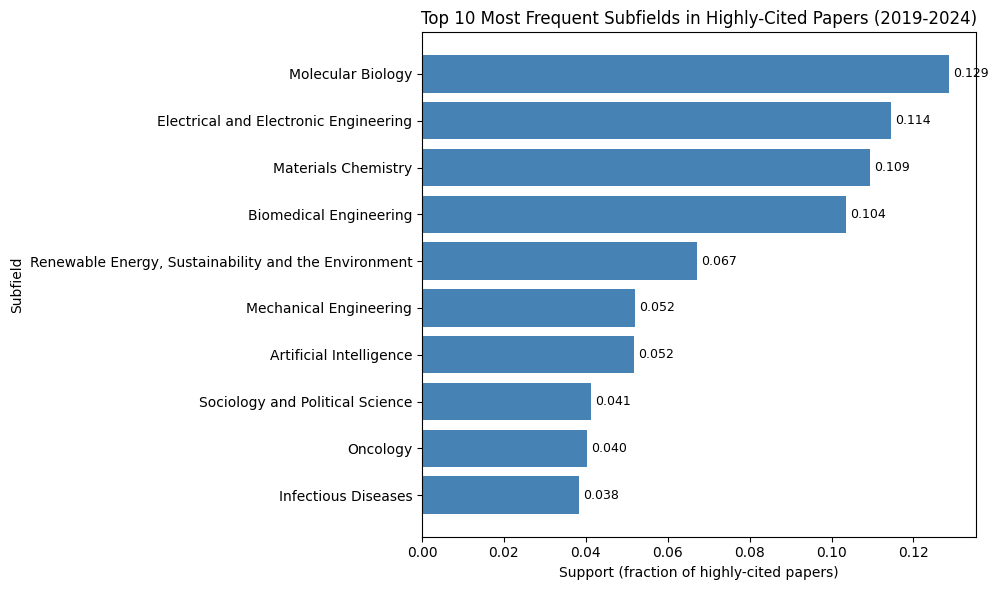

In [61]:
# Get single-item itemsets and pull the subfield name out of the frozenset
top_singles = (
    frequent_itemsets[frequent_itemsets['length'] == 1]
    .copy()
)
top_singles['subfield'] = top_singles['itemsets'].apply(lambda x: list(x)[0])
top_singles = top_singles.sort_values('support', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_singles['subfield'], top_singles['support'], color='steelblue')

# Annotate each bar with its exact support value
for bar, val in zip(bars, top_singles['support']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel("Support (fraction of highly-cited papers)")
ax.set_ylabel("Subfield")
ax.set_title("Top 10 Most Frequent Subfields in Highly-Cited Papers (2019-2024)")
ax.invert_yaxis()  # highest support at the top
plt.tight_layout()
plt.show()

The top 4 subfields all exceed 10% support, which shows that biology and engineering research make up a large amount of highly-cited works between 2019 and 2024. 

---
## Step 12: Visualization — Top 10 Most Frequent Subfield Pairs
A bar chart of the 10 most frequent subfield pairs. Each bar represents a combination of two subfields that co-appear in at least 0.25% of highly-cited papers.

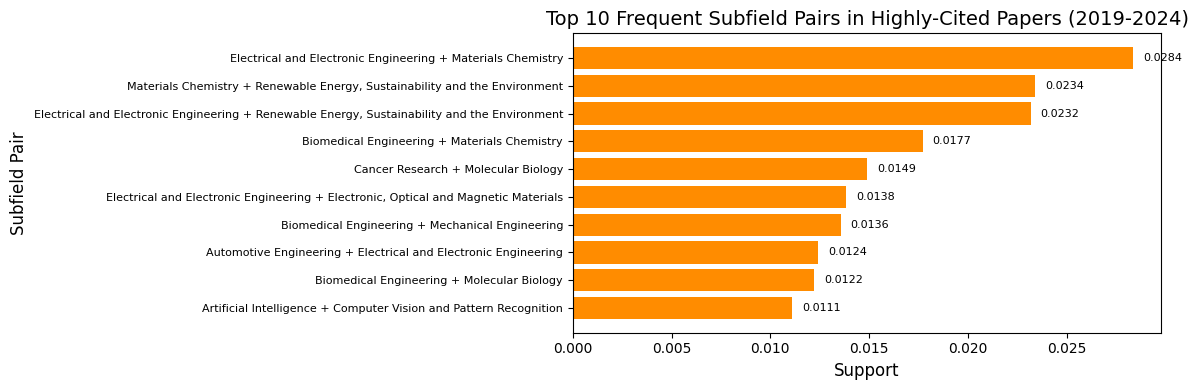

In [62]:
# Get length 2 itemsets and format each pair
pairs = (
    frequent_itemsets[frequent_itemsets['length'] == 2]
    .copy()
)
pairs['pair'] = pairs['itemsets'].apply(lambda x: ' + '.join(sorted(list(x))))
pairs = pairs.sort_values('support', ascending=False).head(10) # top 10 only

# Size the figure height
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(pairs['pair'], pairs['support'], color='darkorange')

# Annotate each bar with its exact support value
for bar, val in zip(bars, pairs['support']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel("Support", fontsize=12)
ax.set_ylabel("Subfield Pair", fontsize=12)
ax.set_title("Top 10 Frequent Subfield Pairs in Highly-Cited Papers (2019-2024)", fontsize=14)
ax.tick_params(axis='y', labelsize=8) # shrink y-axis label font
ax.invert_yaxis()  # most frequent pair at the top

# push the left margin out so long labels aren't cut off
plt.subplots_adjust(left=0.35)
plt.tight_layout()
plt.show()

The top three pairs all involve **Renewable Energy, Sustainability, and the Environment or Materials Chemistry**, which suggests that clean energy and materials research appear together frequently. 

---
## Step 13: Visualization — Scatter Plots

In [63]:
!pip install adjustText --quiet

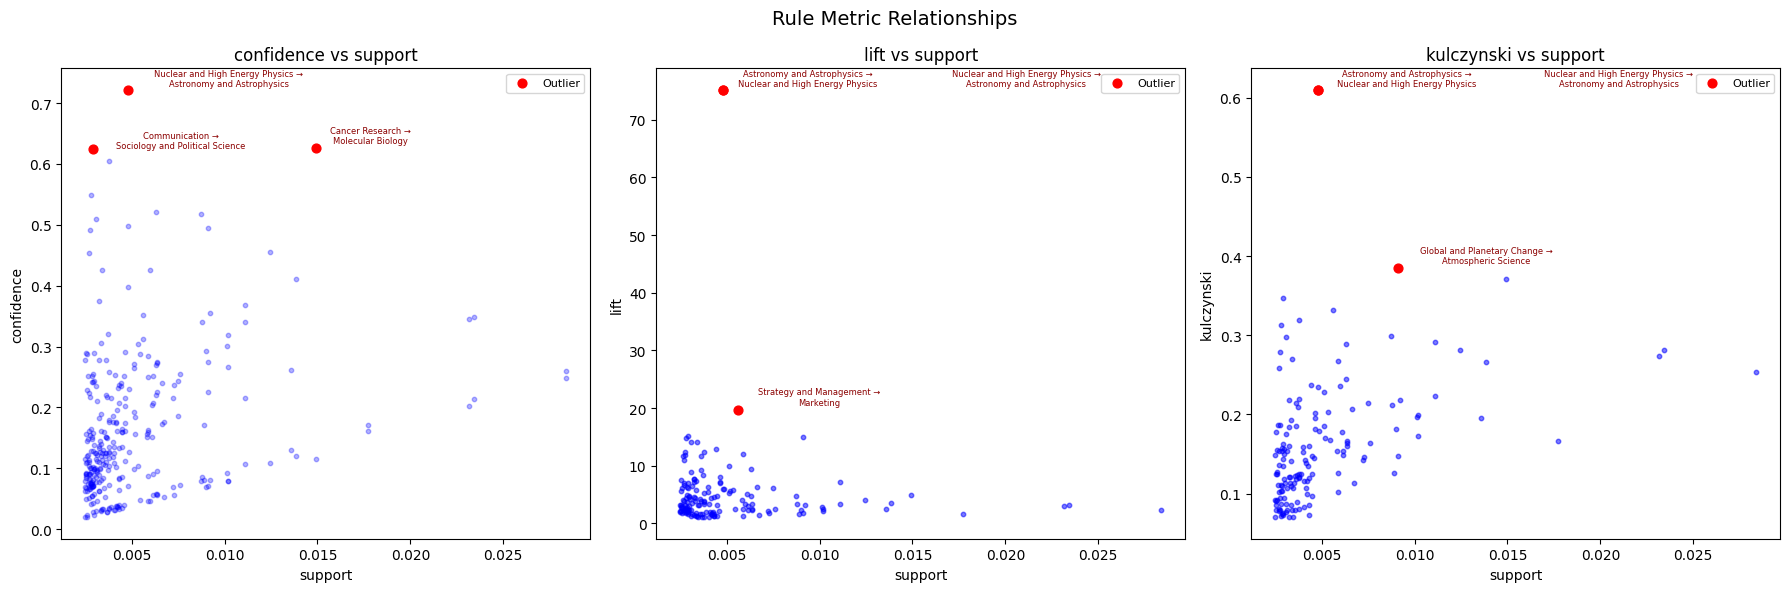

In [64]:
from adjustText import adjust_text

def fmt_set(s):
    # Convert a frozenset of subfield names into a readable string
    return ', '.join(sorted(s))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, y_metric in zip(axes, ['confidence', 'lift', 'kulczynski']):
    ax.scatter(rules['support'], rules[y_metric],
               alpha=0.3, s=10, color='blue')

    # Define outliers as top 3 by the y_metric
    outliers = rules.nlargest(3, y_metric)

    # Highlight outliers in red
    ax.scatter(outliers['support'], outliers[y_metric],
               color='red', s=40, zorder=5, label='Outlier')

    # Collect annotation objects so adjustText can reposition them
    texts = []
    # Annotate each outlier with its antecedent → consequent label
    for _, row in outliers.iterrows():
        label = f"{fmt_set(row['antecedents'])} →\n{fmt_set(row['consequents'])}"
        t = ax.text(row['support'], row[y_metric], label,
                    fontsize=6, color='darkred')
        texts.append(t)

    # Automatically spread labels apart to avoid overlap 
    adjust_text(
        texts,
        ax=ax, 
        force_text=(2.0, 2.0), # push labels farther away from each other 
        force_points=(1.5, 1.5), # push labels farther away from their points
        expand_text=(1.5, 1.5) # add more padding around each label box
    )

    ax.set_xlabel('support')
    ax.set_ylabel(y_metric)
    ax.set_title(f'{y_metric} vs support')
    ax.legend(fontsize=8)

plt.suptitle("Rule Metric Relationships", fontsize=14)
plt.tight_layout()
plt.show()

The three scatter plots show how confidence, lift, and kulczynski each relate to support across all 306 rules. 

The most surprising and strongly associated subfield pairs tend to appear at low support values (below 0.01), meaning they are rare but have highly specific co-occurrences. In the lift plot, **Astronomy and Astrophysics + Nuclear and High Energy Physics** stand out as the highest-lift outlier, which means that this pair co-occurs far more than chance would predict, despite being infrequent. The confidence plot shows that **Astronomy and Astrophysics + Nuclear and High Energy Physics, Communication + Sociology and Political Science, and Cancer Research + Molecular Biology** have the highest confidence, meaning that when one topic appears in a paper, the other almost always does too. 

The kulczynski plot confirms that **Astronomy and Astrophysics + Nuclear and High Energy Physics** has the strongest symmetric relationship, meaning the association holds strongly in both directions.


---
## Step 14: Interpret Top 10 Rules Ranked by Kulczynski
Print the most interesting rules ranked by kulczynski.

- High lift = the two subfields co-occur far more than chance
- High confidence = when the antecedent subfield appears, the consequent almost always does too
- High kulczynski = has strong symmetrical association

In [65]:
print("Top 10 association rules ranked by Kulczynski:")

# Build the top 10 rules sorted by kulczynski 
top_rules = (
    rules
    .sort_values('kulczynski', ascending=False)
    .head(10)
    # Include all metrics for comparison
    [['antecedents', 'consequents', 'support', 'confidence',
      'lift', 'cosine', 'jaccard', 'kulczynski']]
    .reset_index(drop=True)
    .copy()
)

# Convert frozensets to readable strings so the table is readable
top_rules['antecedents'] = top_rules['antecedents'].apply(fmt_set)
top_rules['consequents'] = top_rules['consequents'].apply(fmt_set)

# Create a styled table 
# Blue gradient highlights strongest lift and kulczynski values (most interesting)
# Format each metric column to a consistent number of decimal places
top_rules.style.background_gradient(
    subset=['lift', 'kulczynski'], cmap='Blues'
).format({
    'support':    '{:.4f}',  
    'confidence': '{:.3f}',
    'lift':       '{:.2f}',
    'cosine':     '{:.3f}',
    'jaccard':    '{:.3f}',
    'kulczynski': '{:.3f}',
})

Top 10 association rules ranked by Kulczynski:


,antecedents,consequents,support,confidence,lift,cosine,jaccard,kulczynski
0,Astronomy and Astrophysics,Nuclear and High Energy Physics,0.0048,0.498,75.21,0.600,0.418,0.610
1,Nuclear and High Energy Physics,Astronomy and Astrophysics,0.0048,0.722,75.21,0.600,0.418,0.610
2,Atmospheric Science,Global and Planetary Change,0.0091,0.495,14.89,0.368,0.214,0.385
3,Global and Planetary Change,Atmospheric Science,0.0091,0.275,14.89,0.368,0.214,0.385
4,Cancer Research,Molecular Biology,0.0149,0.626,4.86,0.269,0.108,0.371
5,Molecular Biology,Cancer Research,0.0149,0.116,4.86,0.269,0.108,0.371
6,Sociology and Political Science,Communication,0.0029,0.071,15.14,0.210,0.068,0.347
7,Communication,Sociology and Political Science,0.0029,0.624,15.14,0.210,0.068,0.347
8,Strategy and Management,Marketing,0.0056,0.313,19.67,0.332,0.199,0.332
9,Marketing,Strategy and Management,0.0056,0.352,19.67,0.332,0.199,0.332


The top 10 rules ranked by Kulczynski show that the main subfield pairing that stands out is **Astronomy and Astrophysics + Nuclear and High Energy Physics**. 

Astronomy and Astrophysics + Nuclear and High Energy Physics has the highest lift at **75.21**, meaning these two subfields co-occur about **75 times** more than chance would predict, even though they appear together in less than 1% of papers. These two subfields also have the highest Kulczynski score **(0.610)**, which confirms that it is the most symmetrically strong association. Nuclear and High Energy Physics + Astronomy and Astrophysics also has the highest one-way confidence at **0.722**, meaning when Nuclear and High Energy Physics appears in a paper, Astronomy and Astrophysics shows up more than **72%** of the time.